In [14]:
import pandas as pd
import re
import os
from pathlib import Path
import sys
import numpy as np
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

from deeplc import DeepLC
from psm_utils.psm import PSM
from psm_utils.psm_list import PSMList

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from pyteomics import mgf, mass
from make_predictions.intensity_predictions import (
    obtain_predictions_pairs,
    safe_obtain_rt_predictions,
    safe_obtain_ccs_predictions,
)
from seq_utils.peptide import switch_random_il, get_proforma_bracketed
import metrics.metrics as M

from deeplc import DeepLC
from psm_utils.psm import PSM
from psm_utils.psm_list import PSMList
from seq_utils.peptide import has_il_outside_brackets

import seaborn as sns
from seq_utils.peptide import has_il_outside_brackets

%matplotlib inline

In [15]:
# Load MaxQuant search results (same filtering as retention_time_il_swap.ipynb)
df = pd.read_csv("../temp_data/input_file.txt", sep="\t")
df = df[df["Sequence"].str.len() < 30]

# Parse modifications to ProForma format (for Koina API)
modification_dict_koina = {"(ox)": "UNIMOD:35", "(ac)": "UNIMOD:1", "(oxidation (m))": "UNIMOD:35", "(acetyl (protein n-term))": "UNIMOD:1"}
df["proforma_koina"] = df["Modified sequence"].apply(
    get_proforma_bracketed,
    before_aa=False, isalpha=True, isupper=True,
    pattern="\\([^()]*\\)|\\([^()]*\\([^()]*\\)[^()]*\\)",
    modification_dict=modification_dict_koina,
)

# Parse modifications to ProForma format (for DeepLC - uses modification names)
modification_dict_deeplc = {"(ox)": "Oxidation", "(ac)": "Acetyl", "(oxidation (m))": "Oxidation", "(acetyl (protein n-term))": "Acetyl"}
df["proforma_deeplc"] = df["Modified sequence"].apply(
    get_proforma_bracketed,
    before_aa=False, isalpha=True, isupper=True,
    pattern="\\([^()]*\\)|\\([^()]*\\([^()]*\\)[^()]*\\)",
    modification_dict=modification_dict_deeplc,
)

# Average retention times per unique peptide
merged_df = df.merge(
    df.groupby("proforma_deeplc")["Calibrated retention time"].mean(),
    on="proforma_deeplc", how="left", suffixes=('', '_mean')
)
merged_df = merged_df.drop_duplicates(subset="proforma_deeplc", keep="first")

# For fragment intensity: filter to unmodified, charge 2, with MS/MS scans
df_intensity = df[~df["proforma_koina"].str.contains(r"\[", na=False)].copy()
df_intensity = df_intensity[~np.isnan(df_intensity["MS/MS scan number"])]
df_intensity = df_intensity[df_intensity["Charge"] == 2]

peptides = np.array(df_intensity["proforma_koina"])
charges = np.array(df_intensity["Charge"])
peptides_switched = np.array([switch_random_il(p) for p in peptides])

print(f"Full dataset (for RT): {len(merged_df)} unique peptides")
print(f"Fragment intensity dataset (unmodified, charge 2): {len(df_intensity)} peptides")

Full dataset (for RT): 44227 unique peptides
Fragment intensity dataset (unmodified, charge 2): 121526 peptides


In [16]:
# Load MGF files
def parse_mgf(file_path):
    filename = os.path.splitext(os.path.basename(file_path))[0]
    spectra = {}
    with mgf.read(file_path) as reader:
        for spectrum in tqdm(reader):
            scan_str = spectrum.get("params", {})["title"].split(" scan=")[1].replace("\"", "")
            scan_number = int(scan_str) if scan_str else 0
            spectra[scan_number] = {
                'm/z array': spectrum.get('m/z array', []),
                'intensity array': spectrum.get('intensity array', [])
            }
    return {filename: spectra}

files = [
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_01.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_02.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_03.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_01.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_02.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_03.mgf",
]

mgf_dict = {}
for f in files:
    mgf_dict.update(parse_mgf(f))

100%|██████████| 118174/118174 [00:13<00:00, 8774.55it/s] 


In [17]:
# Load or generate fragment intensity predictions
peptides_switch_predictions_f = "../temp_data/peptides_switch_predictions_puyvelde.csv"
peptides_predictions_f = "../temp_data/peptides_predictions_puyvelde.csv"

def safe_obtain_predictions(peptides_batch, switched, charges, max_retries=3):
    for attempt in range(max_retries):
        try:
            return obtain_predictions_pairs(peptides_batch, switched=switched, 
                                            model="AlphaPeptDeep_ms2_generic", 
                                            charges=charges, collision_energies=27)
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(1)
            else:
                raise RuntimeError(f"Prediction failed after {max_retries} attempts.") from e

if os.path.exists(peptides_switch_predictions_f) and os.path.exists(peptides_predictions_f):
    peptides_switch_predictions = pd.read_csv(peptides_switch_predictions_f)
    peptides_predictions = pd.read_csv(peptides_predictions_f)
else:
    batch_size = 5000
    peptides_switch_predictions_list, peptides_predictions_list = [], []
    for i in tqdm(range(0, len(peptides), batch_size)):
        batch, batch_switched = peptides[i:i+batch_size], peptides_switched[i:i+batch_size]
        batch_charges = charges[i:i+batch_size]
        peptides_switch_predictions_list.append(safe_obtain_predictions(batch_switched, True, batch_charges))
        peptides_predictions_list.append(safe_obtain_predictions(batch, False, batch_charges))
    
    peptides_switch_predictions = pd.concat(peptides_switch_predictions_list, ignore_index=True)
    peptides_predictions = pd.concat(peptides_predictions_list, ignore_index=True)
    peptides_switch_predictions.to_csv(peptides_switch_predictions_f, index=False)
    peptides_predictions.to_csv(peptides_predictions_f, index=False)

# Create lookup dictionaries
dict_predictions = dict(tuple(peptides_predictions.groupby("peptide_sequences")))
dict_predictions_switched = dict(tuple(peptides_switch_predictions.groupby("peptide_sequences")))

In [18]:
# Spectrum annotation and matching functions
def get_theoretical_fragments(peptide_sequence, max_charge=2):
    clean_seq = re.sub(r'\[.*?\]', '', peptide_sequence)
    fragments = []
    seq_len = len(clean_seq)
    for i in range(1, seq_len):
        for z in range(1, max_charge + 1):
            try:
                fragments.append({'ion': f"b{i}", 'charge': z, 'mz': mass.fast_mass(clean_seq[:i], ion_type='b', charge=z)})
            except: pass
            try:
                fragments.append({'ion': f"y{seq_len-i}", 'charge': z, 'mz': mass.fast_mass(clean_seq[i:], ion_type='y', charge=z)})
            except: pass
    return fragments

def annotate_spectrum(mz_array, intensity_array, peptide_sequence, charge, tol_ppm=20):
    mz_array, intensity_array = np.array(mz_array, dtype=np.float64), np.array(intensity_array, dtype=np.float64)
    matched, used_peaks = [], set()
    for frag in get_theoretical_fragments(peptide_sequence, max_charge=charge):
        mz_diff = np.abs((mz_array - frag['mz']) / frag['mz'] * 1e6)
        matches = np.where(mz_diff < tol_ppm)[0]
        if len(matches) > 0:
            best_idx = matches[np.argmin(mz_diff[matches])]
            if best_idx not in used_peaks:
                used_peaks.add(best_idx)
                matched.append({'ion': frag['ion'], 'charge': frag['charge'], 'intensity': intensity_array[best_idx]})
    return pd.DataFrame(matched)

# Match observed spectra to predictions (using df_intensity)
dict_orig_to_swap = dict(zip(peptides, peptides_switched))
dict_il_intensity = {}
for idx, row in tqdm(df_intensity.iterrows(), total=len(df_intensity), desc="Processing"):
    mz_array = mgf_dict[row["Raw file"]][int(row['MS/MS scan number'])]["m/z array"]
    intensity_array = mgf_dict[row["Raw file"]][int(row['MS/MS scan number'])]['intensity array']
    
    df_annotation = annotate_spectrum(mz_array, intensity_array, row['proforma_koina'], row['Charge'])
    if df_annotation.empty:
        continue

    swap_sequence = dict_orig_to_swap.get(row['proforma_koina'])
    sub_df_pred = dict_predictions.get(row['proforma_koina'])
    sub_df_pred_sw = dict_predictions_switched.get(swap_sequence) if swap_sequence else None
    if sub_df_pred is None or sub_df_pred_sw is None:
        continue

    # Parse prediction annotations
    sub_df_pred = sub_df_pred.copy()
    sub_df_pred_sw = sub_df_pred_sw.copy()
    sub_df_pred[['ion', 'charge']] = sub_df_pred['annotation'].str.extract(r"([a-zA-Z]+\d+)\+(\d+)")
    sub_df_pred['charge'] = sub_df_pred['charge'].astype(int)
    sub_df_pred_sw[['ion', 'charge']] = sub_df_pred_sw['annotation'].str.extract(r"([a-zA-Z]+\d+)\+(\d+)")
    sub_df_pred_sw['charge'] = sub_df_pred_sw['charge'].astype(int)
    df_annotation['charge'] = df_annotation['charge'].astype(int)

    # Merge observed with predictions
    merged = pd.merge(df_annotation, sub_df_pred, on=['ion', 'charge'], how='inner')
    merged_all = pd.merge(merged, sub_df_pred_sw, on=['ion', 'charge'], how='inner').drop_duplicates()
    
    if merged_all.empty or max(merged_all["intensity"].values) == 0:
        continue
        
    max_int = max(merged_all["intensity"].values)
    dict_il_intensity[row['proforma_koina']] = {
        "intensity_obs_norm": merged_all["intensity"].values / max_int,
        "intensities_orig": merged_all["intensities_x"].values,
        "intensities_swapped": merged_all["intensities_y"].values,
        "mz_orig": merged_all["mz_x"].values,
    }

Processing: 100%|██████████| 121526/121526 [08:32<00:00, 236.91it/s]


In [19]:
# Score all peptides with all metrics
metric_keys = [
    "x_corr",
    "pearson_correlation",
    "spearman_correlation",
    "kendall_tau",
    "cosine_similarity",
    "spectral_angle",
    "weighted_dot_product",
    "fit",
    "ruzicka_similarity_1",
    "ruzicka_similarity_2",
    "mse",
    "canberra_distance",
    "wasserstein",
    "bray_curtis",
    "mutual_information",
]

scored_dict_seqs = {}
for seq, frag in tqdm(dict_il_intensity.items()):
    score_dict = {}
    inp_base = {"mz1": frag["mz_orig"], "mz2": frag["mz_orig"], 
                "diagnostic_mz": np.array([]), "mz": max(frag["mz_orig"])}
    
    for key in metric_keys:
        try:
            score = getattr(M, key)(intensity1=frag["intensity_obs_norm"], intensity2=frag["intensities_orig"], **inp_base)
        except: score = np.nan
        try:
            score_sw = getattr(M, key)(intensity1=frag["intensity_obs_norm"], intensity2=frag["intensities_swapped"], **inp_base)
        except: score_sw = np.nan
        score_dict[f"{key}|orig"], score_dict[f"{key}|swapped"] = score, score_sw
    
    scored_dict_seqs[seq] = score_dict

scored_df_seqs = pd.DataFrame(scored_dict_seqs).T

100%|██████████| 30596/30596 [01:31<00:00, 335.50it/s]


In [20]:
# Free MGF memory (no longer needed after scoring)
del mgf_dict

# Calculate ratio correct for each metric (matching figure3 methodology)
# Ties (diff == 0) are excluded - this naturally handles non-I/L peptides
# where original and swapped predictions are identical
ratio_correct_dict = {}
for metric_key in metric_keys:
    diff = scored_df_seqs[f"{metric_key}|orig"] - scored_df_seqs[f"{metric_key}|swapped"]
    positive, negative = (diff > 0).sum(), (diff < 0).sum()
    ratio = positive / (positive + negative) if (positive + negative) > 0 else 0.5
    ratio_correct_dict[metric_key] = 1.0 - ratio if ratio < 0.5 else ratio

print(f"Computed ratio correct for {len(ratio_correct_dict)} metrics on {len(scored_df_seqs)} peptides")
for k, v in sorted(ratio_correct_dict.items(), key=lambda x: x[1], reverse=True):
    print(f"  {k:35s}: {v:.4f}")

Computed ratio correct for 15 metrics on 30596 peptides
  ruzicka_similarity_2               : 0.6125
  weighted_dot_product               : 0.6107
  ruzicka_similarity_1               : 0.6096
  pearson_correlation                : 0.6056
  cosine_similarity                  : 0.6031
  spectral_angle                     : 0.6031
  fit                                : 0.6031
  bray_curtis                        : 0.5912
  mse                                : 0.5895
  kendall_tau                        : 0.5874
  canberra_distance                  : 0.5833
  spearman_correlation               : 0.5742
  mutual_information                 : 0.5321
  wasserstein                        : 0.5131
  x_corr                             : 0.5106


In [21]:
# Train/eval split (10% for calibration, 90% for evaluation)
df_train = merged_df.sample(frac=0.1, random_state=42)
df_eval_rt = merged_df.drop(df_train.index).copy()

# Build PSM lists
psm_list_train = PSMList(psm_list=[
    PSM(peptidoform=row["proforma_deeplc"], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_train.iterrows()
])

# Create swapped sequences dict for RT
rt_swap_dict = {}
for idx, row in df_eval_rt.iterrows():
    rt_swap_dict[row["proforma_deeplc"]] = switch_random_il(row["proforma_deeplc"])

psm_list_eval = PSMList(psm_list=[
    PSM(peptidoform=row["proforma_deeplc"], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_eval_rt.iterrows()
])
psm_list_eval_swapped = PSMList(psm_list=[
    PSM(peptidoform=rt_swap_dict[row["proforma_deeplc"]], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_eval_rt.iterrows()
])

# Train DeepLC and make predictions
dlc = DeepLC(deeplc_retrain=False, n_epochs=20)
dlc.calibrate_preds(psm_list_train)
preds_rt = dlc.make_preds(psm_list=psm_list_eval)
preds_rt_swapped = dlc.make_preds(psm_list=psm_list_eval_swapped)

# Add predictions to df_eval_rt
df_eval_rt["predicted_rt"] = preds_rt
df_eval_rt["predicted_rt_swapped"] = preds_rt_swapped
df_eval_rt["swapped_seq"] = [rt_swap_dict[seq] for seq in df_eval_rt["proforma_deeplc"]]

# Compute RT ratio correct (filter to peptides with I/L outside brackets)
df_eval_il = df_eval_rt[df_eval_rt["proforma_deeplc"].apply(has_il_outside_brackets)].copy()
diff_original = (df_eval_il["predicted_rt"] - df_eval_il["Calibrated retention time_mean"]).abs()
diff_swapped = (df_eval_il["predicted_rt_swapped"] - df_eval_il["Calibrated retention time_mean"]).abs()
rt_correct = (diff_original <= diff_swapped).sum()
rt_total = len(df_eval_il)
rt_ratio = rt_correct / rt_total if rt_total > 0 else 0.5
rt_ratio = 1.0 - rt_ratio if rt_ratio < 0.5 else rt_ratio
print(f"RT predictions complete: {len(df_eval_rt)} peptides")
print(f"Retention Time (DeepLC calibrated) - Ratio Correct: {rt_ratio:.4f} ({rt_correct}/{rt_total})")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step
RT predictions complete: 39804 peptides
Retention Time (DeepLC calibrated) - Ratio Correct: 0.6423 (22804/35506)


In [22]:
# ============================================================================
# CCS (Collision Cross Section) PREDICTIONS (using Koina API)
# ============================================================================

# Get unique peptides with I/L for CCS prediction (use same merged_df as RT)
df_ccs = merged_df[merged_df["proforma_koina"].apply(has_il_outside_brackets)].copy()

# Get peptides and their I/L swapped versions
ccs_peptides = df_ccs["proforma_koina"].values
ccs_peptides_switched = np.array([switch_random_il(p) for p in ccs_peptides])
ccs_charges = np.array([2] * len(ccs_peptides))  # Default charge 2

print(f"CCS prediction set: {len(ccs_peptides)} unique peptides with I/L")

# Load or generate CCS predictions
ccs_predictions_f = "../temp_data/ccs_predictions_full.csv"
ccs_predictions_sw_f = "../temp_data/ccs_predictions_sw_full.csv"

if os.path.exists(ccs_predictions_f) and os.path.exists(ccs_predictions_sw_f):
    ccs_predictions = pd.read_csv(ccs_predictions_f)
    ccs_predictions_sw = pd.read_csv(ccs_predictions_sw_f)
    print("Loaded cached CCS predictions")
else:
    # Batch predictions
    batch_size = 5000
    ccs_pred_list, ccs_pred_sw_list = [], []
    for i in tqdm(range(0, len(ccs_peptides), batch_size), desc="CCS Predictions"):
        batch = ccs_peptides[i:i+batch_size]
        batch_sw = ccs_peptides_switched[i:i+batch_size]
        batch_charges = ccs_charges[i:i+batch_size]
        
        ccs_pred_list.append(safe_obtain_ccs_predictions(batch, switched=False, charges=batch_charges))
        ccs_pred_sw_list.append(safe_obtain_ccs_predictions(batch_sw, switched=True, charges=batch_charges))
    
    ccs_predictions = pd.concat(ccs_pred_list, ignore_index=True)
    ccs_predictions_sw = pd.concat(ccs_pred_sw_list, ignore_index=True)
    ccs_predictions.to_csv(ccs_predictions_f, index=False)
    ccs_predictions_sw.to_csv(ccs_predictions_sw_f, index=False)
    print("Generated and saved CCS predictions")

CCS prediction set: 39461 unique peptides with I/L
Loaded cached CCS predictions


In [23]:
# Calculate CCS discriminative power
# Create lookup dictionaries for CCS predictions
ccs_dict = dict(zip(ccs_predictions["peptide_sequences"], ccs_predictions["ccs"]))
ccs_sw_dict = dict(zip(ccs_predictions_sw["peptide_sequences"], ccs_predictions_sw["ccs"]))

# For each original peptide, check if CCS predictions differ
ccs_results = []
for orig_seq, sw_seq in zip(ccs_peptides, ccs_peptides_switched):
    pred_ccs = ccs_dict.get(orig_seq)
    pred_ccs_sw = ccs_sw_dict.get(sw_seq)
    
    if pred_ccs is not None and pred_ccs_sw is not None:
        diff = abs(pred_ccs - pred_ccs_sw)
        ccs_results.append({
            "original_seq": orig_seq,
            "swapped_seq": sw_seq,
            "ccs_original": pred_ccs,
            "ccs_swapped": pred_ccs_sw,
            "diff": diff
        })

ccs_df = pd.DataFrame(ccs_results)

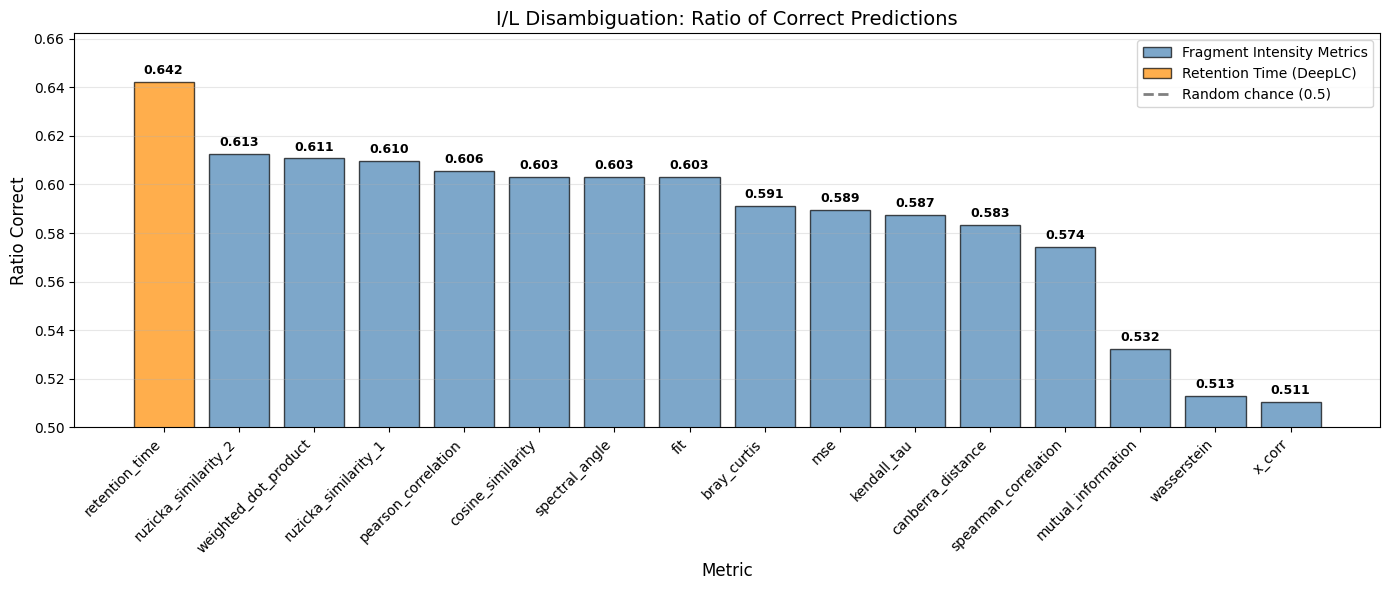

In [24]:
# Collect all results
all_ratios = ratio_correct_dict.copy()
all_ratios["retention_time"] = rt_ratio

# Sort and plot
all_sorted = sorted(all_ratios.keys(), key=lambda x: all_ratios[x], reverse=True)
all_values = [all_ratios[m] for m in all_sorted]

fig, ax = plt.subplots(figsize=(14, 6))

# Color RT differently
colors = ['darkorange' if m == 'retention_time' else 'steelblue' for m in all_sorted]
bars = ax.bar(range(len(all_sorted)), all_values, color=colors, edgecolor='black', alpha=0.7)

for bar, val in zip(bars, all_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', alpha=0.7, label='Fragment Intensity Metrics'),
    Patch(facecolor='darkorange', edgecolor='black', alpha=0.7, label='Retention Time (DeepLC)'),
    plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Random chance (0.5)')
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xticks(range(len(all_sorted)))
ax.set_xticklabels(all_sorted, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Ratio Correct', fontsize=12)
ax.set_xlabel('Metric', fontsize=12)
ax.set_title('I/L Disambiguation: Ratio of Correct Predictions', fontsize=14)
ax.set_ylim([0.5, max(all_values) + 0.02])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("../temp_data/all_metrics_ratio_correct_bargraph.png", dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# Print summary
print("I/L Disambiguation Results Summary:")
print("=" * 50)
for m, v in zip(all_sorted, all_values):
    label = "(RT)" if m == "retention_time" else ""
    print(f"{m:35s}: {v:.4f} {label}")

I/L Disambiguation Results Summary:
retention_time                     : 0.6423 (RT)
ruzicka_similarity_2               : 0.6125 
weighted_dot_product               : 0.6107 
ruzicka_similarity_1               : 0.6096 
pearson_correlation                : 0.6056 
cosine_similarity                  : 0.6031 
spectral_angle                     : 0.6031 
fit                                : 0.6031 
bray_curtis                        : 0.5912 
mse                                : 0.5895 
kendall_tau                        : 0.5874 
canberra_distance                  : 0.5833 
spearman_correlation               : 0.5742 
mutual_information                 : 0.5321 
wasserstein                        : 0.5131 
x_corr                             : 0.5106 


In [26]:
# Function to find position of I/L swap and extract flanking amino acids
def get_swap_info(original_seq, swapped_seq):
    """
    Find where I/L was swapped and extract flanking amino acids.
    Returns: (swap_position, relative_position, flanking_aas)
    flanking_aas is a dict with positions -3 to +3 (excluding 0)
    """
    # Remove modifications for position analysis
    clean_orig = re.sub(r'\[.*?\]', '', original_seq)
    clean_swap = re.sub(r'\[.*?\]', '', swapped_seq)
    
    if len(clean_orig) != len(clean_swap):
        return None, None, None
    
    # Find swap position
    swap_pos = None
    for i, (a, b) in enumerate(zip(clean_orig, clean_swap)):
        if a != b:
            swap_pos = i
            break
    
    if swap_pos is None:
        return None, None, None
    
    seq_len = len(clean_orig)
    relative_pos = swap_pos / (seq_len - 1) if seq_len > 1 else 0.5  # Normalized to 0-1
    
    # Extract flanking amino acids (positions -3 to +3)
    flanking = {}
    for offset in [-3, -2, -1, 1, 2, 3]:
        idx = swap_pos + offset
        if 0 <= idx < seq_len:
            flanking[offset] = clean_orig[idx]
        else:
            flanking[offset] = None  # Out of bounds
    
    return swap_pos, relative_pos, flanking

# Get swap info for all scored peptides (fragment intensity - weighted_dot_product)
swap_data_intensity = []
for seq in scored_df_seqs.index:
    swap_seq = dict_orig_to_swap.get(seq)
    if swap_seq is None:
        continue
    
    swap_pos, rel_pos, flanking = get_swap_info(seq, swap_seq)
    if swap_pos is None:
        continue
    
    # Get scores for weighted_dot_product
    score_orig = scored_df_seqs.loc[seq, "weighted_dot_product|orig"]
    score_swap = scored_df_seqs.loc[seq, "weighted_dot_product|swapped"]
    is_correct = score_orig > score_swap  # Original should score higher
    
    swap_data_intensity.append({
        "sequence": seq,
        "swap_position": swap_pos,
        "relative_position": rel_pos,
        "is_correct": is_correct,
        "seq_length": len(re.sub(r'\[.*?\]', '', seq)),
        **{f"flank_{k}": v for k, v in flanking.items()}
    })

swap_df_intensity = pd.DataFrame(swap_data_intensity)
print(f"Fragment Intensity (weighted_dot_product): {len(swap_df_intensity)} peptides")
print(f"Overall ratio correct: {swap_df_intensity['is_correct'].mean():.4f}")

Fragment Intensity (weighted_dot_product): 27054 peptides
Overall ratio correct: 0.6139


In [27]:
# Get swap info for RT predictions
swap_data_rt = []
for idx, row in df_eval_rt.iterrows():
    orig_seq = row["proforma_deeplc"]
    swap_seq = row["swapped_seq"]
    
    # Check if has I/L
    if not has_il_outside_brackets(orig_seq):
        continue
    
    swap_pos, rel_pos, flanking = get_swap_info(orig_seq, swap_seq)
    if swap_pos is None:
        continue
    
    # Determine which prediction is correct
    obs_rt = row["Calibrated retention time_mean"]
    diff_orig = abs(row["predicted_rt"] - obs_rt)
    diff_swap = abs(row["predicted_rt_swapped"] - obs_rt)
    is_correct = diff_orig <= diff_swap
    
    swap_data_rt.append({
        "sequence": orig_seq,
        "swap_position": swap_pos,
        "relative_position": rel_pos,
        "is_correct": is_correct,
        "seq_length": len(re.sub(r'\[.*?\]', '', orig_seq)),
        **{f"flank_{k}": v for k, v in flanking.items()}
    })

swap_df_rt = pd.DataFrame(swap_data_rt)
print(f"Retention Time (DeepLC): {len(swap_df_rt)} peptides with I/L")
print(f"Overall ratio correct: {swap_df_rt['is_correct'].mean():.4f}")

Retention Time (DeepLC): 35506 peptides with I/L
Overall ratio correct: 0.6423


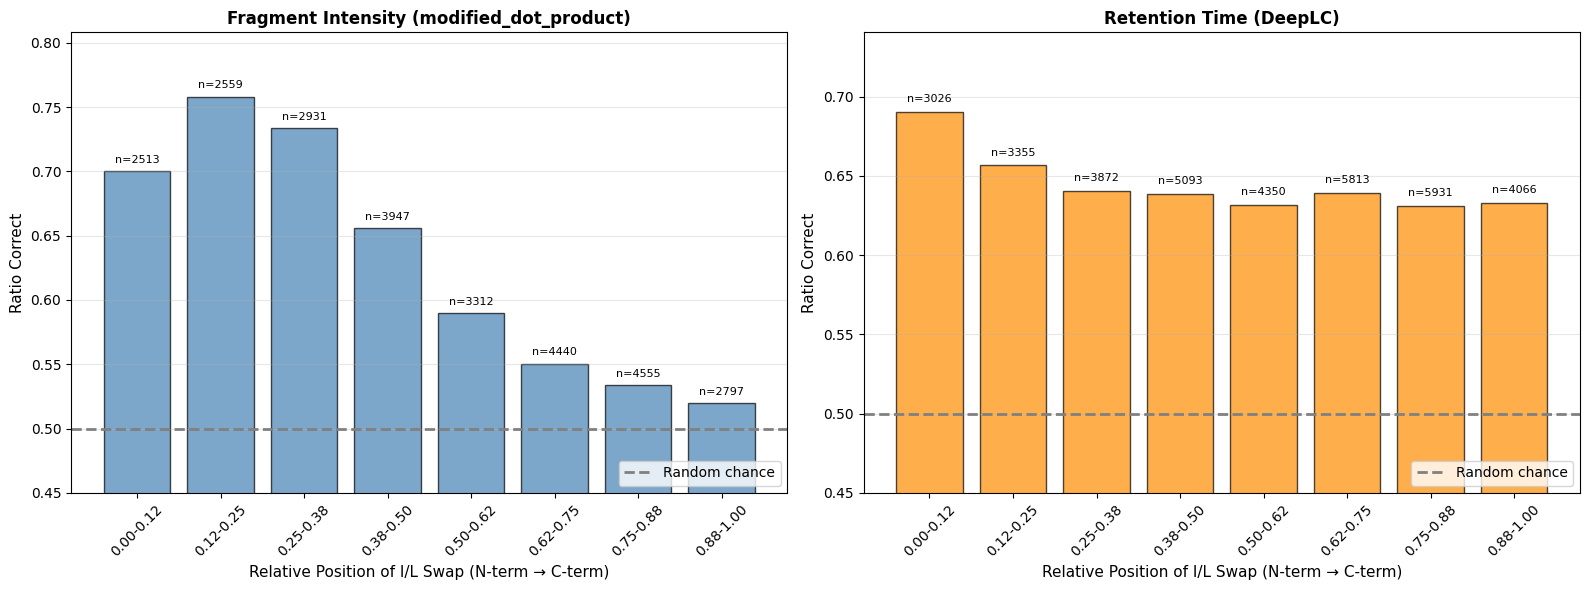


Fragment Intensity - Ratio correct by position bin:
 bin bin_label  ratio_correct  count
   0 0.00-0.12       0.699960   2513
   1 0.12-0.25       0.758109   2559
   2 0.25-0.38       0.733538   2931
   3 0.38-0.50       0.655941   3947
   4 0.50-0.62       0.589674   3312
   5 0.62-0.75       0.550450   4440
   6 0.75-0.88       0.533480   4555
   7 0.88-1.00       0.519843   2797

Retention Time - Ratio correct by position bin:
 bin bin_label  ratio_correct  count
   0 0.00-0.12       0.690681   3026
   1 0.12-0.25       0.656632   3355
   2 0.25-0.38       0.640496   3872
   3 0.38-0.50       0.638523   5093
   4 0.50-0.62       0.631724   4350
   5 0.62-0.75       0.639085   5813
   6 0.75-0.88       0.631091   5931
   7 0.88-1.00       0.632809   4066


In [28]:
def calculate_position_ratios(swap_df, n_bins=8):
    """Calculate ratio correct per position bin."""
    swap_df = swap_df.copy()
    swap_df["position_bin"] = pd.cut(swap_df["relative_position"], bins=n_bins, labels=False)
    
    position_ratios = []
    for bin_idx in range(n_bins):
        bin_data = swap_df[swap_df["position_bin"] == bin_idx]
        if len(bin_data) > 0:
            ratio = bin_data["is_correct"].mean()
            ratio = 1.0 - ratio if ratio < 0.5 else ratio
            position_ratios.append({
                "bin": bin_idx,
                "bin_label": f"{bin_idx/n_bins:.2f}-{(bin_idx+1)/n_bins:.2f}",
                "ratio_correct": ratio,
                "count": len(bin_data)
            })
    return pd.DataFrame(position_ratios)

n_bins = 8
position_df_intensity = calculate_position_ratios(swap_df_intensity, n_bins)
position_df_rt = calculate_position_ratios(swap_df_rt, n_bins)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Modified Dot Product
ax1 = axes[0]
bars1 = ax1.bar(position_df_intensity["bin_label"], position_df_intensity["ratio_correct"], 
                color='steelblue', edgecolor='black', alpha=0.7)
for bar, count in zip(bars1, position_df_intensity["count"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'n={count}', ha='center', va='bottom', fontsize=8)
ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=2, label='Random chance')
ax1.set_xlabel('Relative Position of I/L Swap (N-term \u2192 C-term)', fontsize=11)
ax1.set_ylabel('Ratio Correct', fontsize=11)
ax1.set_title('Fragment Intensity (modified_dot_product)', fontsize=12, fontweight='bold')
ax1.set_ylim([0.45, max(position_df_intensity["ratio_correct"]) + 0.05])
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Retention Time
ax2 = axes[1]
bars2 = ax2.bar(position_df_rt["bin_label"], position_df_rt["ratio_correct"], 
                color='darkorange', edgecolor='black', alpha=0.7)
for bar, count in zip(bars2, position_df_rt["count"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'n={count}', ha='center', va='bottom', fontsize=8)
ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=2, label='Random chance')
ax2.set_xlabel('Relative Position of I/L Swap (N-term \u2192 C-term)', fontsize=11)
ax2.set_ylabel('Ratio Correct', fontsize=11)
ax2.set_title('Retention Time (DeepLC)', fontsize=12, fontweight='bold')
ax2.set_ylim([0.45, max(position_df_rt["ratio_correct"]) + 0.05])
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../temp_data/figure4a_position_ratio_both.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nFragment Intensity - Ratio correct by position bin:")
print(position_df_intensity.to_string(index=False))
print("\nRetention Time - Ratio correct by position bin:")
print(position_df_rt.to_string(index=False))

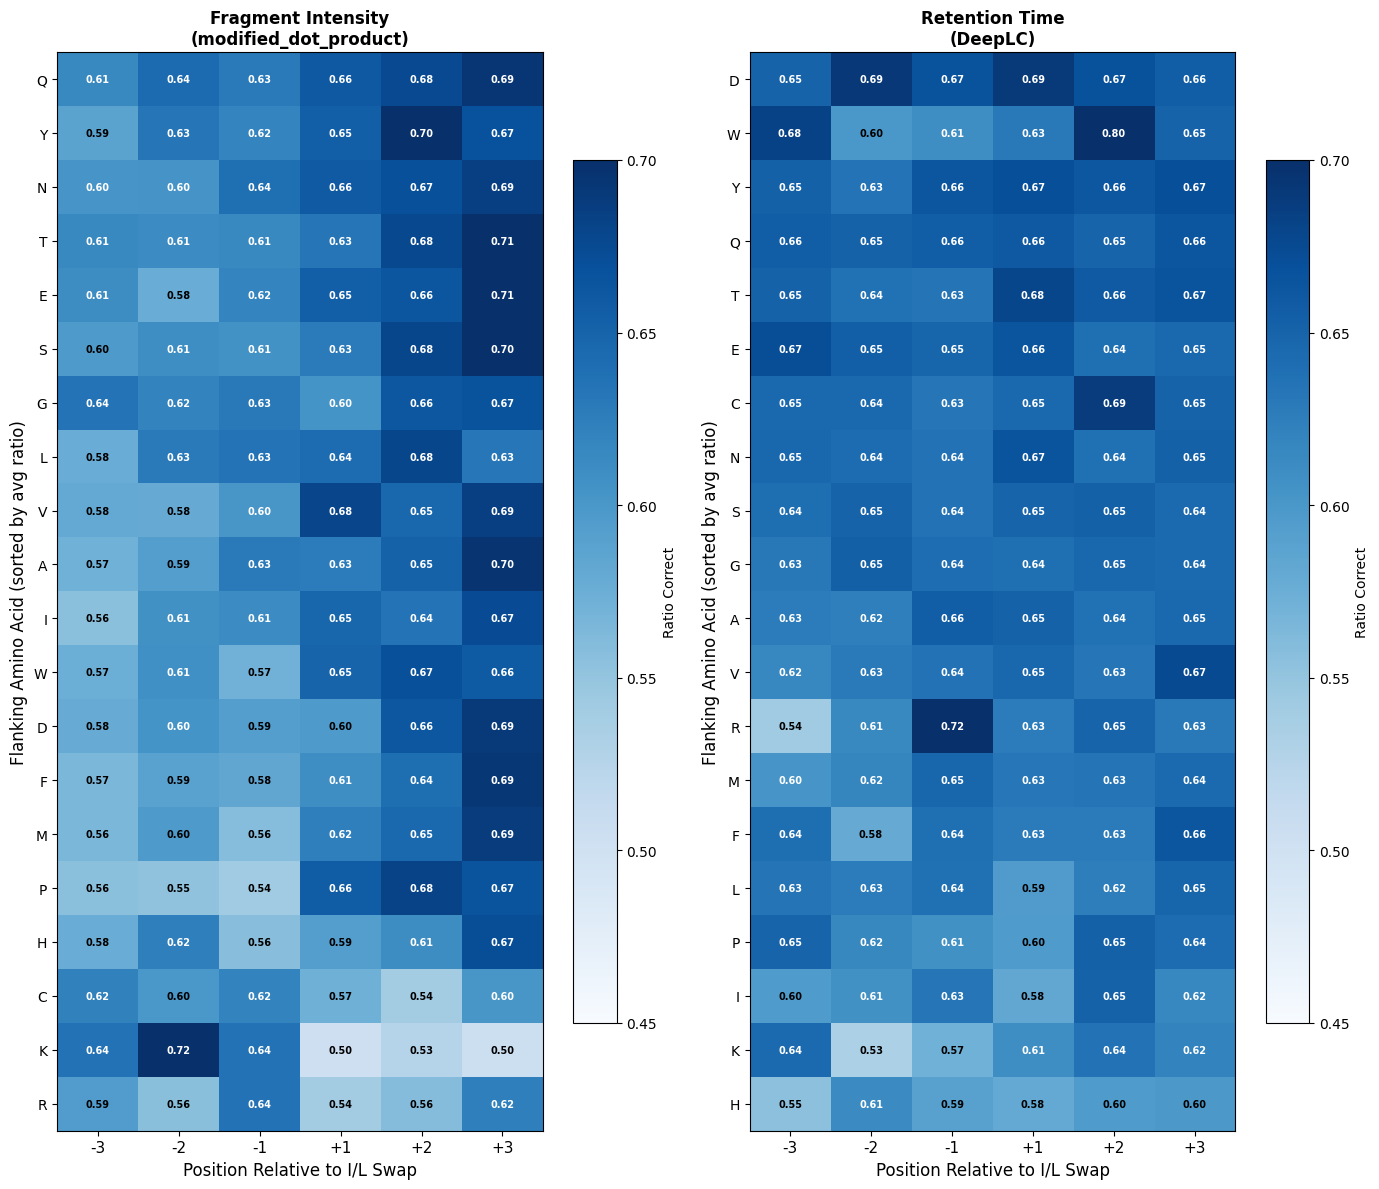

In [29]:
# Standard amino acids
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
positions = [-3, -2, -1, 1, 2, 3]
position_labels = ["-3", "-2", "-1", "+1", "+2", "+3"]

def calculate_flanking_heatmap(swap_df, min_count=10):
    """Calculate 20x6 heatmap data for flanking amino acids."""
    # Shape: rows = amino acids (20), columns = positions (6)
    heatmap_data = np.zeros((len(amino_acids), len(positions)))
    count_data = np.zeros((len(amino_acids), len(positions)))
    
    for j, pos in enumerate(positions):
        col_name = f"flank_{pos}"
        for i, aa in enumerate(amino_acids):
            mask = swap_df[col_name] == aa
            subset = swap_df[mask]
            
            if len(subset) >= min_count:
                ratio = subset["is_correct"].mean()
                ratio = 1.0 - ratio if ratio < 0.5 else ratio
                heatmap_data[i, j] = ratio
                count_data[i, j] = len(subset)
            else:
                heatmap_data[i, j] = np.nan
                count_data[i, j] = len(subset) if len(subset) > 0 else 0
    
    return heatmap_data, count_data

# Calculate heatmaps for both metrics
heatmap_intensity, count_intensity = calculate_flanking_heatmap(swap_df_intensity)
heatmap_rt, count_rt = calculate_flanking_heatmap(swap_df_rt)

# Calculate average ratio per amino acid (ignoring NaN values)
avg_ratio_intensity = np.nanmean(heatmap_intensity, axis=1)
avg_ratio_rt = np.nanmean(heatmap_rt, axis=1)

# Sort amino acids by average ratio (descending) - using intensity for ordering
sort_idx_intensity = np.argsort(avg_ratio_intensity)[::-1]
sort_idx_rt = np.argsort(avg_ratio_rt)[::-1]

# Reorder heatmaps and amino acid labels
heatmap_intensity_sorted = heatmap_intensity[sort_idx_intensity, :]
count_intensity_sorted = count_intensity[sort_idx_intensity, :]
aa_sorted_intensity = [amino_acids[i] for i in sort_idx_intensity]

heatmap_rt_sorted = heatmap_rt[sort_idx_rt, :]
count_rt_sorted = count_rt[sort_idx_rt, :]
aa_sorted_rt = [amino_acids[i] for i in sort_idx_rt]

# Create side-by-side heatmaps (20 rows x 6 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 12))

# Use a single color gradient (sequential colormap)
cmap = sns.color_palette("Blues", as_cmap=True)

# Heatmap 1: Modified Dot Product (sorted by its own average)
ax1 = axes[0]
im1 = ax1.imshow(heatmap_intensity_sorted, cmap=cmap, aspect='auto', vmin=0.45, vmax=0.70)
cbar1 = plt.colorbar(im1, ax=ax1, label='Ratio Correct', shrink=0.8)

ax1.set_xticks(range(len(positions)))
ax1.set_xticklabels(position_labels, fontsize=11)
ax1.set_yticks(range(len(amino_acids)))
ax1.set_yticklabels(aa_sorted_intensity, fontsize=10)
ax1.set_xlabel('Position Relative to I/L Swap', fontsize=12)
ax1.set_ylabel('Flanking Amino Acid (sorted by avg ratio)', fontsize=12)
ax1.set_title('Fragment Intensity\n(modified_dot_product)', fontsize=12, fontweight='bold')

# Add value annotations
for i in range(len(amino_acids)):
    for j in range(len(positions)):
        if not np.isnan(heatmap_intensity_sorted[i, j]):
            val = heatmap_intensity_sorted[i, j]
            color = 'white' if val > 0.60 else 'black'
            ax1.text(j, i, f'{val:.2f}', ha='center', va='center', 
                    fontsize=7, color=color, fontweight='bold')

# Heatmap 2: Retention Time (sorted by its own average)
ax2 = axes[1]
im2 = ax2.imshow(heatmap_rt_sorted, cmap=cmap, aspect='auto', vmin=0.45, vmax=0.70)
cbar2 = plt.colorbar(im2, ax=ax2, label='Ratio Correct', shrink=0.8)

ax2.set_xticks(range(len(positions)))
ax2.set_xticklabels(position_labels, fontsize=11)
ax2.set_yticks(range(len(amino_acids)))
ax2.set_yticklabels(aa_sorted_rt, fontsize=10)
ax2.set_xlabel('Position Relative to I/L Swap', fontsize=12)
ax2.set_ylabel('Flanking Amino Acid (sorted by avg ratio)', fontsize=12)
ax2.set_title('Retention Time\n(DeepLC)', fontsize=12, fontweight='bold')

# Add value annotations
for i in range(len(amino_acids)):
    for j in range(len(positions)):
        if not np.isnan(heatmap_rt_sorted[i, j]):
            val = heatmap_rt_sorted[i, j]
            color = 'white' if val > 0.60 else 'black'
            ax2.text(j, i, f'{val:.2f}', ha='center', va='center', 
                    fontsize=7, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig("../temp_data/figure4b_flanking_heatmap_both.png", dpi=300, bbox_inches='tight')
plt.show()

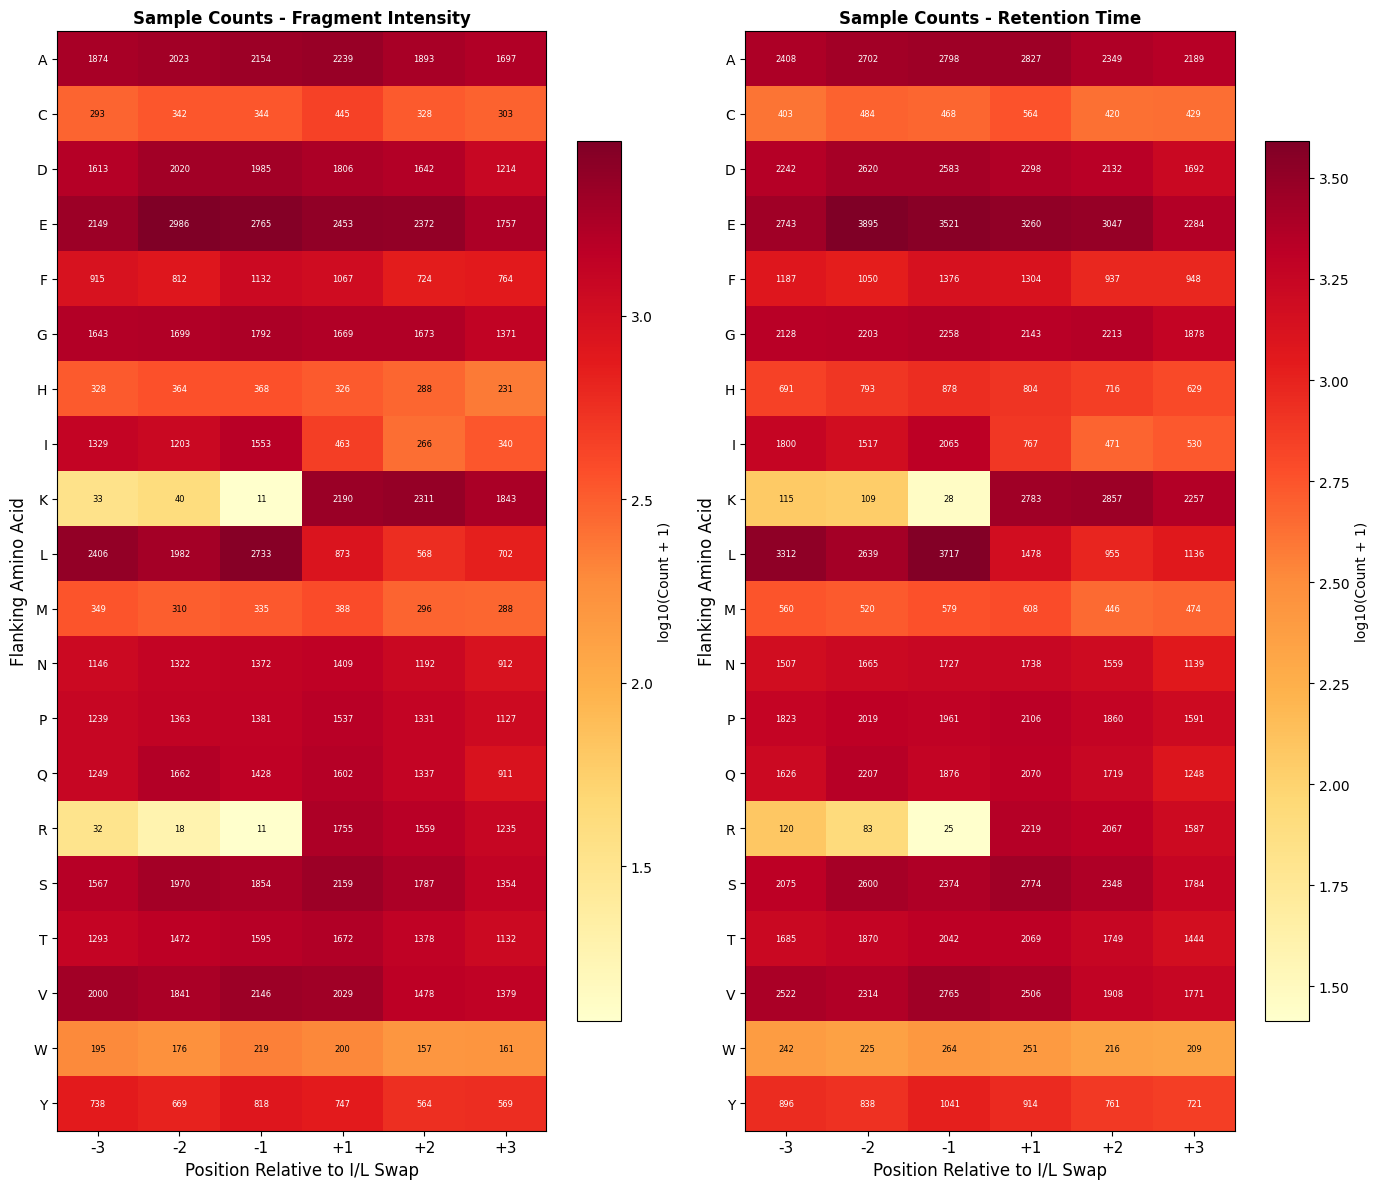

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 12))

# Count Heatmap 1: Fragment Intensity
ax1 = axes[0]
log_counts1 = np.log10(count_intensity + 1)
im1 = ax1.imshow(log_counts1, cmap='YlOrRd', aspect='auto')
cbar1 = plt.colorbar(im1, ax=ax1, label='log10(Count + 1)', shrink=0.8)

ax1.set_xticks(range(len(positions)))
ax1.set_xticklabels(position_labels, fontsize=11)
ax1.set_yticks(range(len(amino_acids)))
ax1.set_yticklabels(amino_acids, fontsize=10)
ax1.set_xlabel('Position Relative to I/L Swap', fontsize=12)
ax1.set_ylabel('Flanking Amino Acid', fontsize=12)
ax1.set_title('Sample Counts - Fragment Intensity', fontsize=12, fontweight='bold')

for i in range(len(amino_acids)):
    for j in range(len(positions)):
        count = int(count_intensity[i, j])
        if count > 0:
            color = 'white' if log_counts1[i, j] > 2.5 else 'black'
            ax1.text(j, i, f'{count}', ha='center', va='center', fontsize=6, color=color)

# Count Heatmap 2: Retention Time
ax2 = axes[1]
log_counts2 = np.log10(count_rt + 1)
im2 = ax2.imshow(log_counts2, cmap='YlOrRd', aspect='auto')
cbar2 = plt.colorbar(im2, ax=ax2, label='log10(Count + 1)', shrink=0.8)

ax2.set_xticks(range(len(positions)))
ax2.set_xticklabels(position_labels, fontsize=11)
ax2.set_yticks(range(len(amino_acids)))
ax2.set_yticklabels(amino_acids, fontsize=10)
ax2.set_xlabel('Position Relative to I/L Swap', fontsize=12)
ax2.set_ylabel('Flanking Amino Acid', fontsize=12)
ax2.set_title('Sample Counts - Retention Time', fontsize=12, fontweight='bold')

for i in range(len(amino_acids)):
    for j in range(len(positions)):
        count = int(count_rt[i, j])
        if count > 0:
            color = 'white' if log_counts2[i, j] > 2.5 else 'black'
            ax2.text(j, i, f'{count}', ha='center', va='center', fontsize=6, color=color)

plt.tight_layout()
plt.savefig("../temp_data/figure4c_flanking_counts_both.png", dpi=300, bbox_inches='tight')
plt.show()